In [1]:
# reference: https://medium.com/data-science/class-imbalance-strategies-a-visual-guide-with-code-8bc8fae71e1a

In [1]:
import os 

os.chdir("..")
print(os.getcwd())

e:\project_archive\new project


In [2]:
# load data
from pathlib import Path
import pandas as pd 
import numpy as np

X_train_path = Path("data/processed/X_train.csv")
y_train_path = Path("data/processed/y_train.npy")

X_test_path = Path("data/processed/X_test.csv")
y_test_path = Path("data/processed/y_test.npy")

X_train = pd.read_csv(X_train_path)
y_train = np.load(y_train_path)

X_test = pd.read_csv(X_test_path)
y_test = np.load(y_test_path)

print(f"X_train loaded successfully: {X_train.shape}")
print(f"y_train loaded successfully: {len(y_train)}")


X_train loaded successfully: (3096, 36)
y_train loaded successfully: 3096


In [6]:
X_train.shape

(3096, 36)

In [4]:
y_train

array([0, 2, 1, ..., 2, 2, 0], shape=(3096,))

In [6]:
y_test

array([0, 2, 2, ..., 2, 1, 2], shape=(1328,))

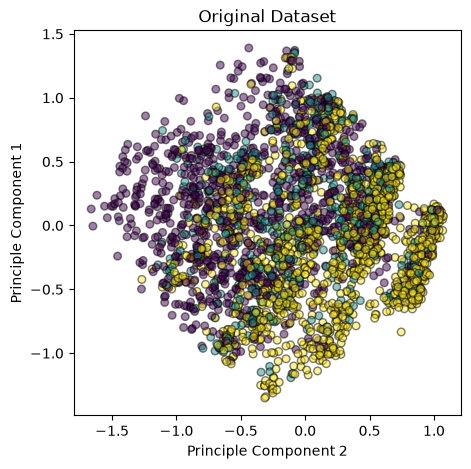

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Scale the dataset on both train and test sets.
# Note that we fit MinMaxScaler on X_train only, not on the entire dataset.
# This prevents data leakage from test set to train set.
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Perform PCA Decomposition on both train and test sets
# Note that we fit PCA on X_train only, not on the entire dataset.
# This prevents data leakage from test set to train set.
pca = PCA(n_components=2)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

# Function for plotting dataset 
def plot_data(X,y,ax,title):
    ax.scatter(X[:, 0], X[:, 1], c=y, alpha=0.5, s = 30, edgecolor=(0,0,0,0.5))
    ax.set_ylabel('Principle Component 1')
    ax.set_xlabel('Principle Component 2')
    if title is not None:
        ax.set_title(title)

# Plot dataset
fig,ax = plt.subplots(figsize=(5, 5))
plot_data(X_train_pca, y_train, ax, title='Original Dataset')

